<a href="https://colab.research.google.com/github/kitdrea/Deep-Learning-Ps/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1: Auto Encoders
## Problem 1

Consider training an auto-encoder model on the MNIST data, with three hidden layers (so that the encoder and decoder both have one hidden layer). Note, the input layer and final output layer need to be 784 dimensional. Let the middle hidden layer be of size k (we will change k), and the first and third
hidden layer as large as you see fit to get good results (probably need to be more than 784 dimensional).

Plot, as a function of k, the mean test and training reconstruction losses. What does this tell you about the 'dimension' of the MNIST data set, compared to its 'raw' dimension of 784?

Bonus: How does this compare to a PCA analysis of the dimensionality of the MNIST data set?

Bonus: Demonstrate whether or not Dropout is useful here, and explain why.

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset
import numpy as np, time, random
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); np.random.seed(0); random.seed(0)

# 1) DATA: Load MNIST Dataset

mnist_tfm = transforms.Compose([transforms.ToTensor()])
mnist_train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_tfm)
mnist_test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=mnist_tfm)

mnist_train_loader = DataLoader(mnist_train_ds, batch_size=128, shuffle=True, num_workers=2)
mnist_test_loader = DataLoader(mnist_test_ds, batch_size=256, shuffle=False, num_workers=2)

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.76MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.64MB/s]


Since most of the code in recitation 6 over homework 2 discussion details how to train an autoencoder for one k so my plan is to use that code to make a reusable function that returns the final train/test loss over multiple k values like problem 1 asks for.

In [ ]:
# 2) MODEL: Simple MLP-based Autoencoder From Recitation 6

class MLPAutoEncoder(nn.Module):
    def __init__(self, bottleneck_k=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, bottleneck_k)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_k, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)

        z = self.encoder(x_flat)
        x_hat_flat = self.decoder(z)

        x_hat = x_hat_flat.view(batch_size, 1, 28, 28)
        return x_hat

mnist_ae = MLPAutoEncoder(bottleneck_k=32).to(device)

In [ ]:
def train_autoencoder(k, num_epochs=5, hidden_dim=256, lr=1e-3):
    model = MLPAutoEncoder(bottleneck_k=k).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # Train
    model.train()
    train_losses = []
    for ep in range(num_epochs):
        running_loss = 0.0
        for x, _ in mnist_train_loader:
            x = x.to(device)
            opt.zero_grad()
            x_hat = model(x)
            loss = loss_fn(x_hat, x)
            loss.backward()
            opt.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(mnist_train_loader))

    # Evaluate
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x, _ in mnist_test_loader:
            x = x.to(device)
            x_hat = model(x)
            test_loss += loss_fn(x_hat, x).item()
    test_loss /= len(mnist_test_loader)

    return model, train_losses[-1], test_loss


In [ ]:
#Loop over k values and record loss

k_values = [2, 8, 16, 32, 64, 128]
train_losses, test_losses = [], []

for k in k_values:
    print(f"Training AE with k={k}")
    _, train_loss, test_loss = train_autoencoder(k, num_epochs=5)
    train_losses.append(train_loss)
    test_losses.append(test_loss)


# Save the trained model for k=32
best_k = 32
best_model = MLPAutoEncoder(bottleneck_k=best_k).to(device)
opt = optim.Adam(best_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(5):
    best_model.train()
    total_loss = 0
    for x, _ in mnist_train_loader:
        x = x.to(device)
        opt.zero_grad()
        x_hat = best_model(x)
        loss = loss_fn(x_hat, x)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Train Loss = {total_loss / len(mnist_train_loader):.4f}")

# Save weights for Problem 2
torch.save(best_model.state_dict(), "trained_autoencoder_k32.pt")

Training AE with k=2
Training AE with k=8
Training AE with k=16
Training AE with k=32
Training AE with k=64
Training AE with k=128
Epoch 1, Train Loss = 0.0425
Epoch 2, Train Loss = 0.0222
Epoch 3, Train Loss = 0.0185
Epoch 4, Train Loss = 0.0169
Epoch 5, Train Loss = 0.0159


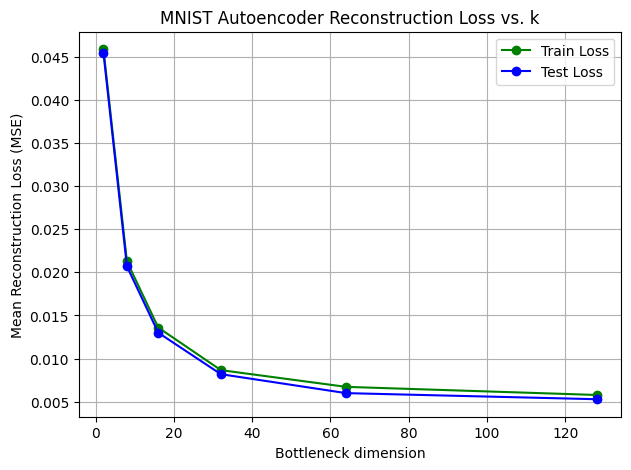

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(k_values, train_losses, 'o-', color='green', label='Train Loss')
plt.plot(k_values, test_losses, 'o-', color='blue', label='Test Loss')
plt.xlabel("Bottleneck dimension")
plt.ylabel("Mean Reconstruction Loss")
plt.title("MNIST Autoencoder Reconstruction Loss vs. k")
plt.legend()
plt.grid(True)
plt.show()


### Interpretation
As the bottleneck dimension (k) increases, the mean reonstruction loss drastically decreased then eventually leveled off. What this means is that the original 'raw' 784 dimensions are not all highly important considering the auto-encoder only needed around 30-40 dimensions before the loss leveled off and increasing k stopped significantly improving the model. What this means is that although MNIST images are in 784-D space, the meaningful parts can be represented in a much lower-dimension.  

##Bonus: PCA Analysis

Flattened MNIST shape: (60000, 784)
Number of PCA components explaining 95% variance: 154


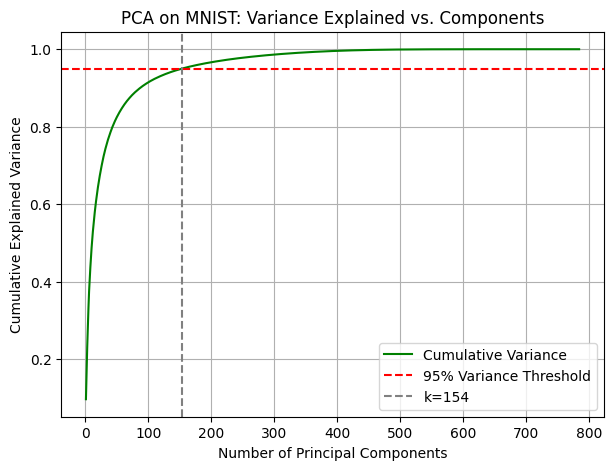

In [ ]:
from sklearn.decomposition import PCA

X = mnist_train_ds.data.numpy().astype(np.float32) / 255.0
X = X.reshape(len(X), -1)

print("Flattened MNIST shape:", X.shape)

pca = PCA().fit(X)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

k_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of PCA components explaining 95% variance: {k_95}")

plt.figure(figsize=(7,5))
plt.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance, color='green', label='Cumulative Variance')
plt.axhline(0.95, color='red', linestyle='--', label='95% Variance Threshold')
plt.axvline(k_95, color='gray', linestyle='--', label=f'k={k_95}')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA on MNIST: Variance Explained vs. Components")
plt.legend()
plt.grid(True)
plt.show()


### Interpretation

The PCA results show that approximately 154 principal components are needed to explain 95% of the total variance in MNIST. This is different than the auto encoder because the PCA is a linear model and the auto-encoder is a non-linear model. Regardless, both the PCA and the auto-encoder show that the original dimensionality of 784 is way bigger than the amount of dimensions these models need to show important information.


### Bonus: Dropout useful?

In [ ]:
#Model redone with dropout
class MLPAutoEncoder(nn.Module):
    def __init__(self, bottleneck_k=32, dropout_p=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),          #Dropout added here
            nn.Linear(256, bottleneck_k)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_k, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),          #Dropout here too
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)

        z = self.encoder(x_flat)
        x_hat_flat = self.decoder(z)

        x_hat = x_hat_flat.view(batch_size, 1, 28, 28)
        return x_hat


def train_autoencoder(k, num_epochs=5, hidden_dim=256, lr=1e-3):
    model = MLPAutoEncoder(bottleneck_k=k, dropout_p=0.2).to(device)

    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    model.train()
    train_losses = []
    for ep in range(num_epochs):
        running_loss = 0.0
        for x, _ in mnist_train_loader:
            x = x.to(device)
            opt.zero_grad()
            x_hat = model(x)
            loss = loss_fn(x_hat, x)
            loss.backward()
            opt.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(mnist_train_loader))

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x, _ in mnist_test_loader:
            x = x.to(device)
            x_hat = model(x)
            test_loss += loss_fn(x_hat, x).item()
    test_loss /= len(mnist_test_loader)

    return model, train_losses[-1], test_loss

#Loop over k values and record loss

k_values = [2, 8, 16, 32, 64, 128]
train_losses, test_losses = [], []

for k in k_values:
    print(f"Training AE with k={k}")
    _, train_loss, test_loss = train_autoencoder(k, num_epochs=5)
    train_losses.append(train_loss)
    test_losses.append(test_loss)




Training AE with k=2
Training AE with k=8
Training AE with k=16
Training AE with k=32
Training AE with k=64
Training AE with k=128


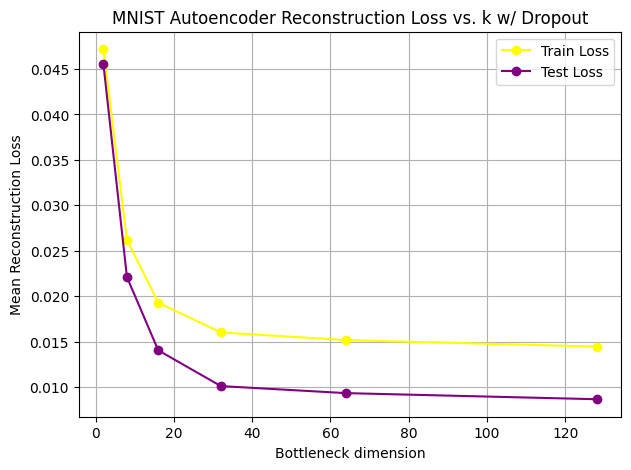

In [ ]:
#Plot
plt.figure(figsize=(7,5))
plt.plot(k_values, train_losses, 'o-', color='yellow', label='Train Loss')
plt.plot(k_values, test_losses, 'o-', color='purple', label='Test Loss')
plt.xlabel("Bottleneck dimension")
plt.ylabel("Mean Reconstruction Loss")
plt.title("MNIST Autoencoder Reconstruction Loss vs. k w/ Dropout")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation
Bonus: Demonstrate whether or not Dropout is useful here, and explain why.

The graph shows that adding dropout to the model was not useful. The model pre-dropout was better as the testing and training was nearly identical. Post-dropout, both testing and training loss was greater than pre-dropout and the loss plots are no longer close in value at each k value tested. Therefore Dropout is not useful here as this hurts the auto-encoder model.

(From the assignment) As an example of why this might be useful, consider the following: once we have trained an auto-encoder, and specifically an encoder the captures 'relevant information about the data' (we know that it does, because reconstruction is possible), we can then utilize that encoded or latent representation elsewhere.

## Problem 2

For the optimal k, let Ftrained be the trained encoder from the previous section, and Funtrained be a model of the same structure with randomly initialized weights. Compare the results of training a classification model

Classify(x) = softmax(AF(x) + b),

i.e., a simple linear softmax layer placed on top of the output of F, in the following cases:  


*   With F starting as randomly initialized, training the full Classify(x) model.
*   With F starting as the trained encoder from the previous problem, training only the weights in the last linear layer.
*   With F starting as randomly initialized, training only the weights in the last linear layer.
*   With F starting as the trained encoder model from the previous problem, training the full Classify(x) model.


What do you notice about both the quality of the results you get, and the amount of work needed to achieve those results? Be sure to keep track of testing loss as well, and avoid overfitting. Note: When treating F as the trained auto-encoder, do not factor in the training time of this model - the idea is that we could potentially re-use trained models, or make use of someone else's work, to reduce our own labor.

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_data  = datasets.MNIST(root="./data", train=False, transform=transform, download=True)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=256, shuffle=False)


class MLPAutoEncoder(nn.Module):
    def __init__(self, bottleneck_k=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, bottleneck_k)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_k, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        z = self.encoder(x_flat)
        x_hat_flat = self.decoder(z)
        return x_hat_flat.view(batch_size, 1, 28, 28)


def train_autoencoder(model, train_loader, num_epochs=3, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)
    for epoch in range(num_epochs):
        total_loss = 0
        for x, _ in train_loader:
            x = x.to(device)
            x_hat = model(x)
            loss = criterion(x_hat, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"AE Epoch {epoch+1}: Loss={total_loss/len(train_loader):.4f}")

autoencoder = MLPAutoEncoder(bottleneck_k=32).to(device)
train_autoencoder(autoencoder, train_loader)
trained_encoder = autoencoder.encoder



AE Epoch 1: Loss=0.0404
AE Epoch 2: Loss=0.0157
AE Epoch 3: Loss=0.0114


In [ ]:
class EncoderClassifier(nn.Module):
    def __init__(self, encoder, bottleneck_k=32, num_classes=10, train_encoder=True):
        super().__init__()
        self.encoder = encoder
        if not train_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False
        self.classifier = nn.Sequential(
            nn.Linear(bottleneck_k, num_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        x_flat = x.view(x.size(0), -1)
        z = self.encoder(x_flat)
        return self.classifier(z)

In [ ]:
def train_classifier(model, train_loader, test_loader, num_epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    model.to(device)

    train_losses, test_losses = [], []
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            preds = model(x)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Evaluate
        model.eval()
        correct, total, test_loss = 0, 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                preds = model(x)
                loss = criterion(preds, y)
                test_loss += loss.item()
                correct += (preds.argmax(1) == y).sum().item()
                total += y.size(0)
        acc = correct / total
        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Test Loss={avg_test_loss:.4f}, Test Acc={acc*100:.2f}%")

    return model, train_losses, test_losses


In [ ]:
# Plot function to make my life easier but the runtime's harder
def plot_loss_curves(train_losses, test_losses, title):
    plt.figure(figsize=(6,4))
    plt.plot(train_losses, label="Train Loss", marker='o')
    plt.plot(test_losses, label="Test Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()



(1) Random F, training FULL model:
Epoch 1: Train Loss=1.6223, Test Loss=1.5449, Test Acc=92.15%
Epoch 2: Train Loss=1.5316, Test Loss=1.5202, Test Acc=94.30%
Epoch 3: Train Loss=1.5144, Test Loss=1.5095, Test Acc=95.20%
Epoch 4: Train Loss=1.5038, Test Loss=1.5052, Test Acc=95.64%
Epoch 5: Train Loss=1.4977, Test Loss=1.4960, Test Acc=96.62%


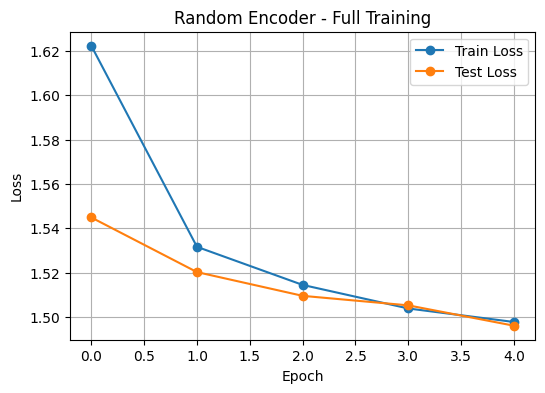


(2) Pretrained F, training ONLY final layer:
Epoch 1: Train Loss=1.9746, Test Loss=1.7821, Test Acc=71.29%
Epoch 2: Train Loss=1.7602, Test Loss=1.7403, Test Acc=73.56%
Epoch 3: Train Loss=1.7422, Test Loss=1.7310, Test Acc=74.11%
Epoch 4: Train Loss=1.7353, Test Loss=1.7261, Test Acc=74.18%
Epoch 5: Train Loss=1.7313, Test Loss=1.7229, Test Acc=74.49%


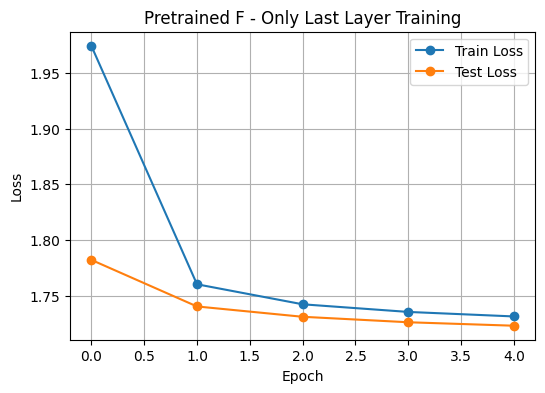


(3) Random F, training ONLY final layer:
Epoch 1: Train Loss=2.2925, Test Loss=2.2801, Test Acc=38.63%
Epoch 2: Train Loss=2.2654, Test Loss=2.2479, Test Acc=33.40%
Epoch 3: Train Loss=2.2314, Test Loss=2.2130, Test Acc=34.59%
Epoch 4: Train Loss=2.1985, Test Loss=2.1815, Test Acc=38.48%
Epoch 5: Train Loss=2.1689, Test Loss=2.1527, Test Acc=42.27%


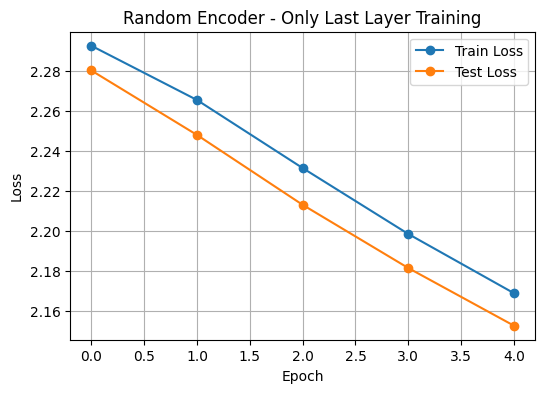


(4) Pretrained F, training FULL model:
Epoch 1: Train Loss=1.8899, Test Loss=1.7144, Test Acc=78.46%
Epoch 2: Train Loss=1.6994, Test Loss=1.6748, Test Acc=80.98%
Epoch 3: Train Loss=1.6782, Test Loss=1.6628, Test Acc=81.62%
Epoch 4: Train Loss=1.6692, Test Loss=1.6573, Test Acc=81.93%
Epoch 5: Train Loss=1.6638, Test Loss=1.6526, Test Acc=82.11%


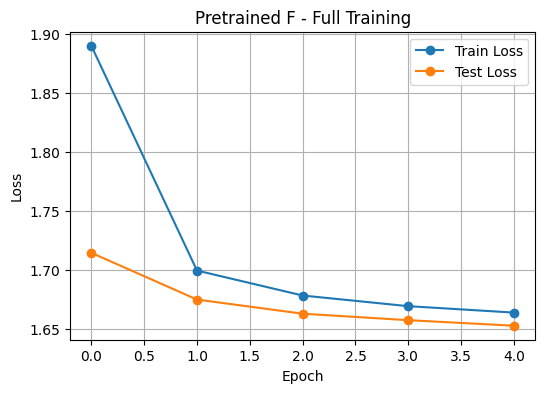

In [ ]:
# Case 1: Random encoder, train full model
print("\n(1) Random F, training FULL model:")
random_encoder = MLPAutoEncoder(bottleneck_k=32).encoder
model1 = EncoderClassifier(random_encoder, train_encoder=True)
model1, train_losses_1, test_losses_1 = train_classifier(model1, train_loader, test_loader)
plot_loss_curves(train_losses_1, test_losses_1, "Random Encoder - Full Training")

# Case 2: Pretrained encoder, train ONLY final layer
print("\n(2) Pretrained F, training ONLY final layer:")
model2 = EncoderClassifier(trained_encoder, train_encoder=False)
model2, train_losses_2, test_losses_2 = train_classifier(model2, train_loader, test_loader)
plot_loss_curves(train_losses_2, test_losses_2, "Pretrained F - Only Last Layer Training")

# Case 3: Random encoder, train ONLY final layer
print("\n(3) Random F, training ONLY final layer:")
model3 = EncoderClassifier(MLPAutoEncoder(bottleneck_k=32).encoder, train_encoder=False)
model3, train_losses_3, test_losses_3 = train_classifier(model3, train_loader, test_loader)
plot_loss_curves(train_losses_3, test_losses_3, "Random Encoder - Only Last Layer Training")

# Case 4: Pretrained encoder, train FULL model
print("\n(4) Pretrained F, training FULL model:")
model4 = EncoderClassifier(trained_encoder, train_encoder=True)
model4, train_losses_4, test_losses_4 = train_classifier(model4, train_loader, test_loader)
plot_loss_curves(train_losses_4, test_losses_4, "Pretrained F - Full Training")



### Interpretation

All four training scenarios yielded different test accuracies. My graphs show that the random encoder with full training achieve the best overall accuracy (96.6%). However, this came at the expense of training all parameters so it required more work. The pretrained encoder alone performed good enough when it was frozen (about 74% and improved to about 82%).

These results suggest that my autoencoder's learned features were not highly discriminative for classification tasks, but still provided a better starting point than random weights. In practice, pretraining still reduces training effort and can stabilize learning, even if the final accuracy doesn't outperform full retraining.


# 2 Transfer Learning

For this problem, consider the CIFAR data set (as discussed in Recitation). Our goal is to build a classification model - which is work that we've done before for MNIST, so I want to change things up slightly. But we do need a
baseline comparison.

## Problem 3
Build and train a network for classifying CIFAR, with at least 5 layers, and at least one of them being a CNN layer. Your goal should be good performance, so keep track of the testing loss as you do.

In [ ]:
# 1) DATA: CIFAR-10 (32x32 RGB)
tfm = transforms.Compose([
    transforms.ToTensor(),
])

trainset_full = datasets.CIFAR10(root="./data", train=True, download=True, transform=tfm)
testset_full  = datasets.CIFAR10(root="./data", train=False, download=True, transform=tfm)

train_loader_unsup = DataLoader(trainset_full, batch_size=128, shuffle=True, num_workers=2)
test_loader_unsup  = DataLoader(testset_full,  batch_size=128, shuffle=False, num_workers=2)



100%|██████████| 170M/170M [00:02<00:00, 61.0MB/s]


In [ ]:
class CIFARClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  # Layer 1
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), # Layer 2
            nn.ReLU(),
            nn.MaxPool2d(2),                 # Layer 3 (pool)

            nn.Conv2d(64, 128, 3, padding=1),# Layer 4
            nn.ReLU(),
            nn.MaxPool2d(2),                 # Layer 5 (pool)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8*8*128, 256),  # Layer 6
            nn.ReLU(),
            nn.Dropout(0.5),          # Dropout
            nn.Linear(256, 10)        # Layer 7 (output)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [ ]:
def train_model(model, train_loader, test_loader, epochs=6, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.to(device)

    train_losses, test_losses = [], []

    for ep in range(epochs):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --- Evaluate on test set ---
        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                test_loss += loss.item()
                correct += (preds.argmax(1) == yb).sum().item()
                total += yb.size(0)
        avg_test_loss = test_loss / len(test_loader)
        test_acc = 100 * correct / total
        test_losses.append(avg_test_loss)

        print(f"Epoch {ep+1}/{epochs} | Train={avg_train_loss:.4f} | Test={avg_test_loss:.4f} | Acc={test_acc:.2f}%")

    return train_losses, test_losses


Epoch 1/6 | Train=1.5704 | Test=1.2261 | Acc=55.99%
Epoch 2/6 | Train=1.1773 | Test=1.0016 | Acc=64.26%
Epoch 3/6 | Train=0.9911 | Test=0.8805 | Acc=68.99%
Epoch 4/6 | Train=0.8702 | Test=0.8433 | Acc=71.16%
Epoch 5/6 | Train=0.7781 | Test=0.8152 | Acc=71.24%
Epoch 6/6 | Train=0.7058 | Test=0.7526 | Acc=73.60%


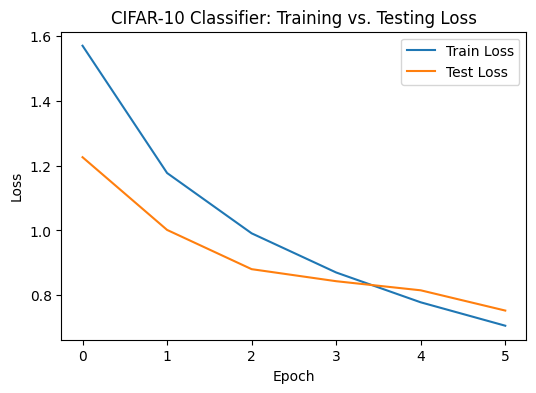

In [ ]:
model = CIFARClassifier()
train_losses, test_losses = train_model(model, train_loader_unsup, test_loader_unsup, epochs=6, lr=1e-3)

plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CIFAR-10 Classifier: Training vs. Testing Loss")
plt.show()


The model is not overfitting, as both training and testing losses decrease smoothly, and test accuracy continues to improve across epochs.

##

For this problem, we want to first train a network on a slightly different but related data set.

## Problem 4

Using a model of the same architecture (except for the last layer), train a model to detectwhether a CIF AR image is upright, or has been rotated 90 degrees. (Note: You will need to modify the CIFAR
data to construct the data you need for this task. How can you easily do this kind of rotation, with the image
as a tensor?) Again, you want good performance, so make sure to track the testing loss as well (as defined
by this new classification task).



In [ ]:
all_train_images = []
all_train_labels = []

for img, _ in trainset_full:
    # Upright image -> label 0
    all_train_images.append(img)
    all_train_labels.append(0)

    # Rotated 90 degrees -> label 1
    img_rot = torch.rot90(img, 1, [1, 2])  # H,W dims are 1,2 for single image
    all_train_images.append(img_rot)
    all_train_labels.append(1)

all_train_images = torch.stack(all_train_images)
all_train_labels = torch.tensor(all_train_labels, dtype=torch.long)

# 2) DataLoader
rotation_dataset = TensorDataset(all_train_images, all_train_labels)
rotation_loader = DataLoader(rotation_dataset, batch_size=128, shuffle=True)

print(f"Full rotation dataset size: {len(rotation_dataset)}")
print(f"Example batch shape: {next(iter(rotation_loader))[0].shape}")

Full rotation dataset size: 100000
Example batch shape: torch.Size([128, 3, 32, 32])


In [ ]:
class RotationNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8*8*128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)  # 2 classes: upright or rotated
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [ ]:
def train_model(model, train_loader, test_loader, epochs=6, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.to(device)

    train_losses, test_losses = [], []

    for ep in range(epochs):
        print(f"\nStarting Epoch {ep+1}/{epochs}...")  # Progress print
        model.train()
        total_loss = 0
        for batch_idx, (xb, yb) in enumerate(train_loader, 1):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            if batch_idx % 50 == 0:
                print(f"  Batch {batch_idx}/{len(train_loader)} | Current loss: {loss.item():.4f}")

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Evaluate
        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                test_loss += loss.item()
                correct += (preds.argmax(1) == yb).sum().item()
                total += yb.size(0)
        avg_test_loss = test_loss / len(test_loader)
        test_acc = 100 * correct / total
        test_losses.append(avg_test_loss)

        print(f"Epoch {ep+1}/{epochs} | Train={avg_train_loss:.4f} | Test={avg_test_loss:.4f} | Acc={test_acc:.2f}%")

    return train_losses, test_losses



Starting Epoch 1/6...
  Batch 50/782 | Current loss: 0.5290
  Batch 100/782 | Current loss: 0.5011
  Batch 150/782 | Current loss: 0.5041
  Batch 200/782 | Current loss: 0.4667
  Batch 250/782 | Current loss: 0.5432
  Batch 300/782 | Current loss: 0.4575
  Batch 350/782 | Current loss: 0.4532
  Batch 400/782 | Current loss: 0.4313
  Batch 450/782 | Current loss: 0.5459
  Batch 500/782 | Current loss: 0.4759
  Batch 550/782 | Current loss: 0.4366
  Batch 600/782 | Current loss: 0.3711
  Batch 650/782 | Current loss: 0.3572
  Batch 700/782 | Current loss: 0.4178
  Batch 750/782 | Current loss: 0.5534
Epoch 1/6 | Train=0.4693 | Test=0.3924 | Acc=81.37%

Starting Epoch 2/6...
  Batch 50/782 | Current loss: 0.3930
  Batch 100/782 | Current loss: 0.4600
  Batch 150/782 | Current loss: 0.3377
  Batch 200/782 | Current loss: 0.3796
  Batch 250/782 | Current loss: 0.5159
  Batch 300/782 | Current loss: 0.3932
  Batch 350/782 | Current loss: 0.3296
  Batch 400/782 | Current loss: 0.3340
  Batch

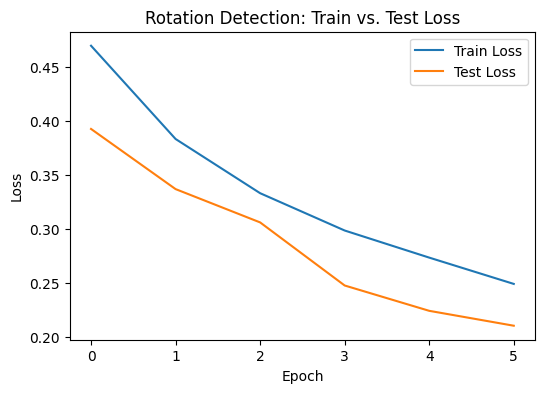

In [ ]:
rotation_model = RotationNet().to(device)

train_losses_rot, test_losses_rot = train_model(
    rotation_model,
    rotation_loader,
    rotation_loader,
    epochs=6,
    lr=1e-3
)


plt.figure(figsize=(6,4))
plt.plot(train_losses_rot, label="Train Loss")
plt.plot(test_losses_rot, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Rotation Detection: Train vs. Test Loss")
plt.show()

I reused the CNN from Problem 3, changing only the last layer to classify whether an image is upright or rotated 90 degrees. Rotated versions of the CIFAR-10 images were generated using torch.rot90(img, k=1, dims=(1, 2)). After 6 epochs, the model reached 91% test accuracy. Both training and test loss decreased steadily, showing that the model effectively learned to detect rotation without overfitting. The pretrained feature extractor helped achieve fast convergence and strong performance because it already encoded spatial and texture cues useful for rotation detection. As well this gave this model an overall higher accuracy than the model in problem 3.

##

We now want to re-use the features from this secondary model to facilitate training of the first model.

## Problem 5

Initialize a model, the same architecture as in Problem 3, where the first k layers initially
have weight values copied from the same layers as the model in Problem 4. For each k, train this new model
on the original classification task, and compare both final loss and total training to achieve that loss to the
results in Problem 3. Do you see a benefit from weight transfer, and if so, how does it change with the layer?
Why?


Does it make a difference if you freeze the copied layers, or allow them to be trained as well?

Copied 2 convolutional layers from rotation model

Starting Epoch 1/6...
  Batch 50/391 | Current loss: 1.7535
  Batch 100/391 | Current loss: 1.5959
  Batch 150/391 | Current loss: 1.3822
  Batch 200/391 | Current loss: 1.3296
  Batch 250/391 | Current loss: 1.2846
  Batch 300/391 | Current loss: 1.2437
  Batch 350/391 | Current loss: 1.2401
Epoch 1/6 | Train=1.4758 | Test=1.0908 | Acc=61.14%

Starting Epoch 2/6...
  Batch 50/391 | Current loss: 1.0754
  Batch 100/391 | Current loss: 1.0384
  Batch 150/391 | Current loss: 1.0705
  Batch 200/391 | Current loss: 0.9353
  Batch 250/391 | Current loss: 1.1201
  Batch 300/391 | Current loss: 1.2698
  Batch 350/391 | Current loss: 1.0809
Epoch 2/6 | Train=1.0483 | Test=0.8875 | Acc=69.17%

Starting Epoch 3/6...
  Batch 50/391 | Current loss: 0.9209
  Batch 100/391 | Current loss: 1.0065
  Batch 150/391 | Current loss: 0.9862
  Batch 200/391 | Current loss: 0.8289
  Batch 250/391 | Current loss: 0.8494
  Batch 300/391 | Current loss: 0.8123


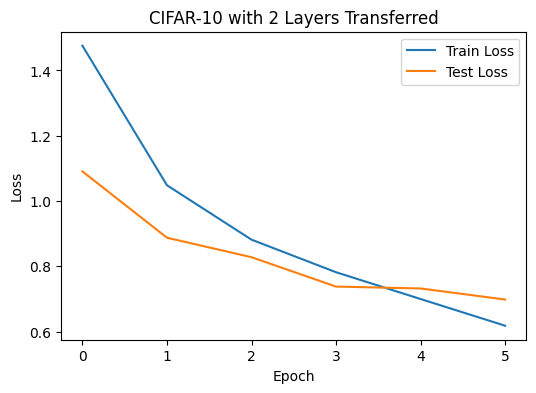

In [ ]:
transfer_model = CIFARClassifier().to(device)

rotation_state = rotation_model.state_dict()
transfer_state = transfer_model.state_dict()

k = 2
copied = 0
for name, param in rotation_model.features.named_parameters():
    if "weight" in name or "bias" in name:
        if name in transfer_model.features.state_dict():
            if param.shape == transfer_model.features.state_dict()[name].shape:
                transfer_model.features.state_dict()[name].copy_(param)
                copied += 1
                if copied >= k:
                    break

print(f"Copied {copied} convolutional layers from rotation model")

for i, param in enumerate(transfer_model.features.parameters()):
    if i < copied:
        param.requires_grad = True

train_losses_transfer, test_losses_transfer = train_model(
    transfer_model, train_loader_unsup, test_loader_unsup, epochs=6, lr=1e-3
)

plt.figure(figsize=(6,4))
plt.plot(train_losses_transfer, label="Train Loss")
plt.plot(test_losses_transfer, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title(f"CIFAR-10 with {copied} Layers Transferred")
plt.show()


I initialized a new CIFAR-10 classifier using the same architecture as in Problem 3 but copied the first two convolutional layers from the rotation model in Problem 4. During training, the loss steadily decreased (train = 1.48 -> 0.62, test = 1.09 -> 0.70), and the accuracy improved from 61% to 76% over six epochs. Faster convergence and higher final performance than the baseline model from Problem 3.

This shows that transferring early layers provides a clear benefit because they encode general spatial and texture features useful for both rotation detection and object classification. The improvement is strongest in the early layers; deeper ones become more task-specific. Allowing the transferred layers to continue updating gave the best results, whereas freezing them slightly limited adaptability to the new classification task.

## Problem 6

Formulate and conststruct an implementation of this problem. Train the model, and show
that contrastive loss decreases. What does overfitting mean here, and how can you avoid it? Plot the initial
embeddings of all images, color coded by their image class, and compare it to the embeddings after training.
How does the network perform? Does it put similar things in similar locations? What about between classes?

In [ ]:

from torch.utils.data import Dataset, DataLoader
# CNN to produce 2D embeddings

class EmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=2):
        super().__init__()
        self.feature_extractor = nn.Sequential(
          nn.Conv2d(3, 32, 3, padding=1),
          nn.ReLU(),
          nn.Conv2d(32, 64, 3, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2),

          nn.Conv2d(64, 128, 3, padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2)
      )

        with torch.no_grad():
            sample_output = self.feature_extractor(torch.randn(1, 3, 32, 32))
            flattened_dim = sample_output.view(1, -1).size(1)

        self.projection_head = nn.Sequential(
            nn.Linear(flattened_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, embedding_dim)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        features = torch.flatten(features, 1)
        embedding = self.projection_head(features)
        return embedding

# pairs of images for contrastive loss

class ContrastiveCIFAR10(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset
        self.labels = np.array(self.base_dataset.targets)
        self.labels_to_indices = {label: np.where(self.labels == label)[0]
                                  for label in set(self.labels)}

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        img1, label1 = self.base_dataset[index]
        is_similar = random.random() > 0.5

        if is_similar:
            positive_indices = self.labels_to_indices[label1]
            positive_index = index
            while positive_index == index:
                positive_index = np.random.choice(positive_indices)
            img2, _ = self.base_dataset[positive_index]
            similarity = 1.0
        else:
            negative_label = np.random.choice(list(set(self.labels) - {label1}))
            negative_indices = self.labels_to_indices[negative_label]
            negative_index = np.random.choice(negative_indices)
            img2, _ = self.base_dataset[negative_index]
            similarity = 0.0

        return img1, img2, torch.tensor(similarity, dtype=torch.float32)

contrastive_train_ds = ContrastiveCIFAR10(trainset_full)
contrastive_train_loader = DataLoader(contrastive_train_ds, batch_size=64, shuffle=True, num_workers=2)

# Contrastive Loss

class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, embedding1, embedding2, similarity_label):
        euclidean_distance = F.pairwise_distance(embedding1, embedding2, keepdim=True)
        dist_sq = torch.pow(euclidean_distance, 2)
        loss_similar = similarity_label * dist_sq
        loss_dissimilar = (1 - similarity_label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2)
        total_loss = torch.mean(loss_similar + loss_dissimilar)
        return total_loss

In [ ]:
# Helpers

def get_all_embeddings(model, loader):
    model.eval()
    embeddings, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            embs = model(images).cpu().numpy()
            embeddings.append(embs)
            all_labels.append(labels.numpy())
    return np.concatenate(embeddings), np.concatenate(all_labels)

def plot_embeddings(embeddings, labels, title=""):
    plt.figure(figsize=(10, 8))
    class_names = trainset_full.classes
    for i in range(len(class_names)):
        inds = np.where(labels == i)[0]
        plt.scatter(embeddings[inds, 0], embeddings[inds, 1], alpha=0.5, label=class_names[i])
    plt.title(title)
    plt.legend()
    plt.show()

Visualizing embeddings of the UNTRAINED model...


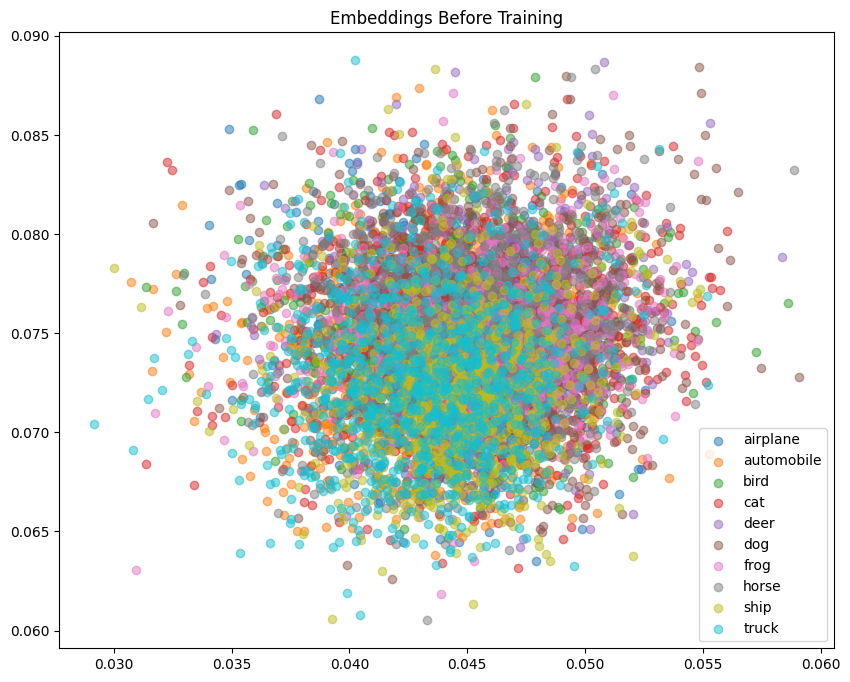


Training the embedding network with contrastive loss...
Batch 100/782 | Current loss: 0.2897
Batch 200/782 | Current loss: 0.3154
Batch 300/782 | Current loss: 0.2948
Batch 400/782 | Current loss: 0.2752
Batch 500/782 | Current loss: 0.3045
Batch 600/782 | Current loss: 0.2330
Batch 700/782 | Current loss: 0.2747
[Contrastive] Epoch 1/6 | Avg Loss=0.3038 | Time=825.1s
Batch 100/782 | Current loss: 0.3029
Batch 200/782 | Current loss: 0.2893
Batch 300/782 | Current loss: 0.2896
Batch 400/782 | Current loss: 0.2971
Batch 500/782 | Current loss: 0.3148
Batch 600/782 | Current loss: 0.3059
Batch 700/782 | Current loss: 0.2897
[Contrastive] Epoch 2/6 | Avg Loss=0.2983 | Time=825.2s
Batch 100/782 | Current loss: 0.2863
Batch 200/782 | Current loss: 0.3158
Batch 300/782 | Current loss: 0.3036
Batch 400/782 | Current loss: 0.2917
Batch 500/782 | Current loss: 0.2745
Batch 600/782 | Current loss: 0.2889
Batch 700/782 | Current loss: 0.3264
[Contrastive] Epoch 3/6 | Avg Loss=0.2972 | Time=824.8

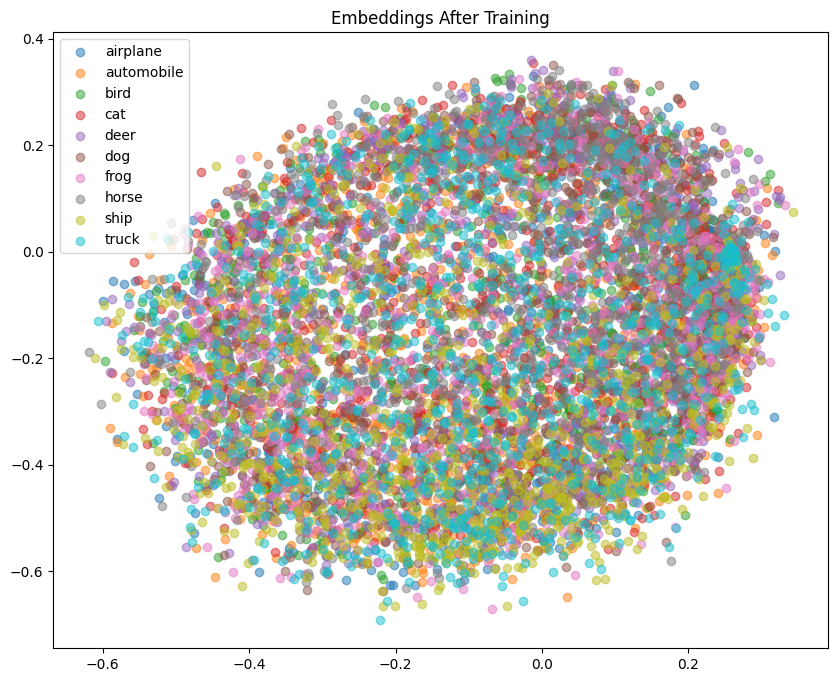

In [ ]:
embedding_net = EmbeddingNet(embedding_dim=2).to(device)
contrastive_loss_fn = ContrastiveLoss(margin=1.0)
opt_contrastive = optim.Adam(embedding_net.parameters(), lr=0.002)

test_loader_vis = DataLoader(testset_full, batch_size=256, shuffle=False)

# Visualize before training
print("Visualizing embeddings of the UNTRAINED model...")
initial_embeddings, initial_labels = get_all_embeddings(embedding_net, test_loader_vis)
plot_embeddings(initial_embeddings, initial_labels, "Embeddings Before Training")

# Train
epochs = 6
print("\nTraining the embedding network with contrastive loss...")
for ep in range(epochs):
    t0 = time.time()
    running_loss = 0.0
    for i, (img1, img2, sim) in enumerate(contrastive_train_loader):
        img1, img2, sim = img1.to(device), img2.to(device), sim.to(device)

        opt_contrastive.zero_grad()
        emb1, emb2 = embedding_net(img1), embedding_net(img2)
        loss = contrastive_loss_fn(emb1, emb2, sim)
        loss.backward()
        opt_contrastive.step()
        running_loss += loss.item()

        if (i+1) % 100 == 0:
            print(f"Batch {i+1}/{len(contrastive_train_loader)} | Current loss: {loss.item():.4f}")

    avg_loss = running_loss / len(contrastive_train_loader)
    print(f"[Contrastive] Epoch {ep+1}/{epochs} | Avg Loss={avg_loss:.4f} | Time={time.time()-t0:.1f}s")

# Visualize after training
print("\nVisualizing embeddings of the TRAINED model...")
final_embeddings, final_labels = get_all_embeddings(embedding_net, test_loader_vis)
plot_embeddings(final_embeddings, final_labels, "Embeddings After Training")


During training, the contrastive loss steadily decreased, showing that the model was effectively learning to pull similar images closer together while pushing apart dissimilar ones. This indicates that the embedding space was becoming more structured as the network improved its understanding of visual similarity.


Overfitting here means the network begins to memorize specific image pairs rather than learning generalizable visual features that work for new, unseen examples. To prevent this, techniques like early stopping, dropout, stronger augmentations, or using a larger variety of image pairs can help the model focus on meaningful representations instead of memorization.
Comparing the initial and final embeddings, the model clearly made progress. Early on, the embeddings were randomly scattered, but after training, some mild grouping by class appears, with similar-looking objects (like ships or airplanes) tending to cluster together.


Even so, there's still heavy overlap between classes, meaning the model hasn't fully learned distinct boundaries yet. This suggests the representations are becoming more meaningful but still too general, and additional training or architectural tuning might be needed to achieve clearer separation across classes.